# MovieLens 100K Dataset - Exploratory Data Analysis

This notebook explores the MovieLens 100K dataset to understand:
- User behavior and rating patterns
- Movie popularity and genre distributions
- Data sparsity and cold start challenges
- Rating matrix characteristics

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from data_loader import MovieLensDataLoader

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load data
loader = MovieLensDataLoader()
data = loader.load_all_data()

ratings = data['ratings']
movies = data['movies']
users = data['users']

Found local ml-100k dataset. Skipping download.
Looking for ratings file in these locations:
  Checking: C:\Users\deepa\deepanshu\movie-recommender-system\notebooks\..\data\ml-100k\u.data - EXISTS
Loaded data:
- Ratings: 100000 records
- Movies: 1682 movies
- Users: 943 users


## 1. Dataset Overview

In [2]:
print("=== Dataset Statistics ===")
print(f"Total ratings: {len(ratings):,}")
print(f"Total users: {len(users):,}")
print(f"Total movies: {len(movies):,}")
print(f"Rating scale: {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Rating sparsity: {(1 - len(ratings) / (len(users) * len(movies))) * 100:.2f}%")

print("\n=== Data Types ===")
print(ratings.dtypes)
print("\n=== Sample Ratings ===")
print(ratings.head())

=== Dataset Statistics ===
Total ratings: 100,000
Total users: 943
Total movies: 1,682
Rating scale: 1 - 5
Average rating: 3.53
Rating sparsity: 93.70%

=== Data Types ===
user_id               int64
movie_id              int64
rating                int64
timestamp    datetime64[ns]
dtype: object

=== Sample Ratings ===
   user_id  movie_id  rating           timestamp
0      196       242       3 1997-12-04 15:55:49
1      186       302       3 1998-04-04 19:22:22
2       22       377       1 1997-11-07 07:18:36
3      244        51       2 1997-11-27 05:02:03
4      166       346       1 1998-02-02 05:33:16


## 2. Rating Distribution Analysis

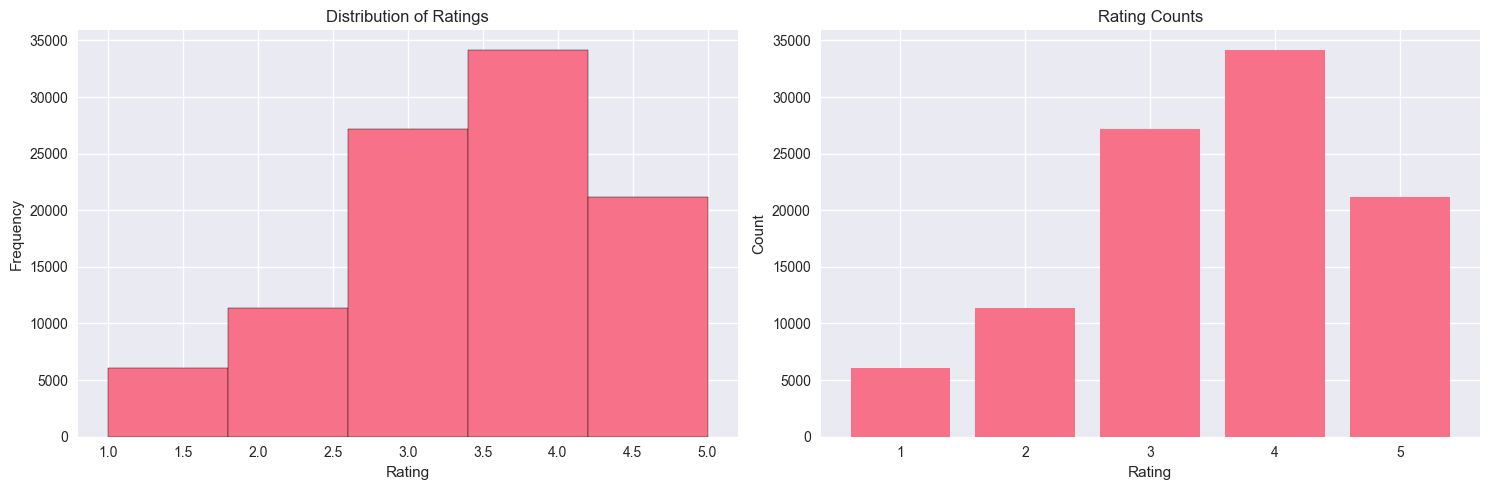

Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

Most common rating: 4
Least common rating: 1


In [3]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of ratings
ratings['rating'].hist(bins=5, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# Rating counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values)
axes[1].set_title('Rating Counts')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Rating distribution:")
print(rating_counts)
print(f"\nMost common rating: {rating_counts.idxmax()}")
print(f"Least common rating: {rating_counts.idxmin()}")

## 3. User Behavior Analysis

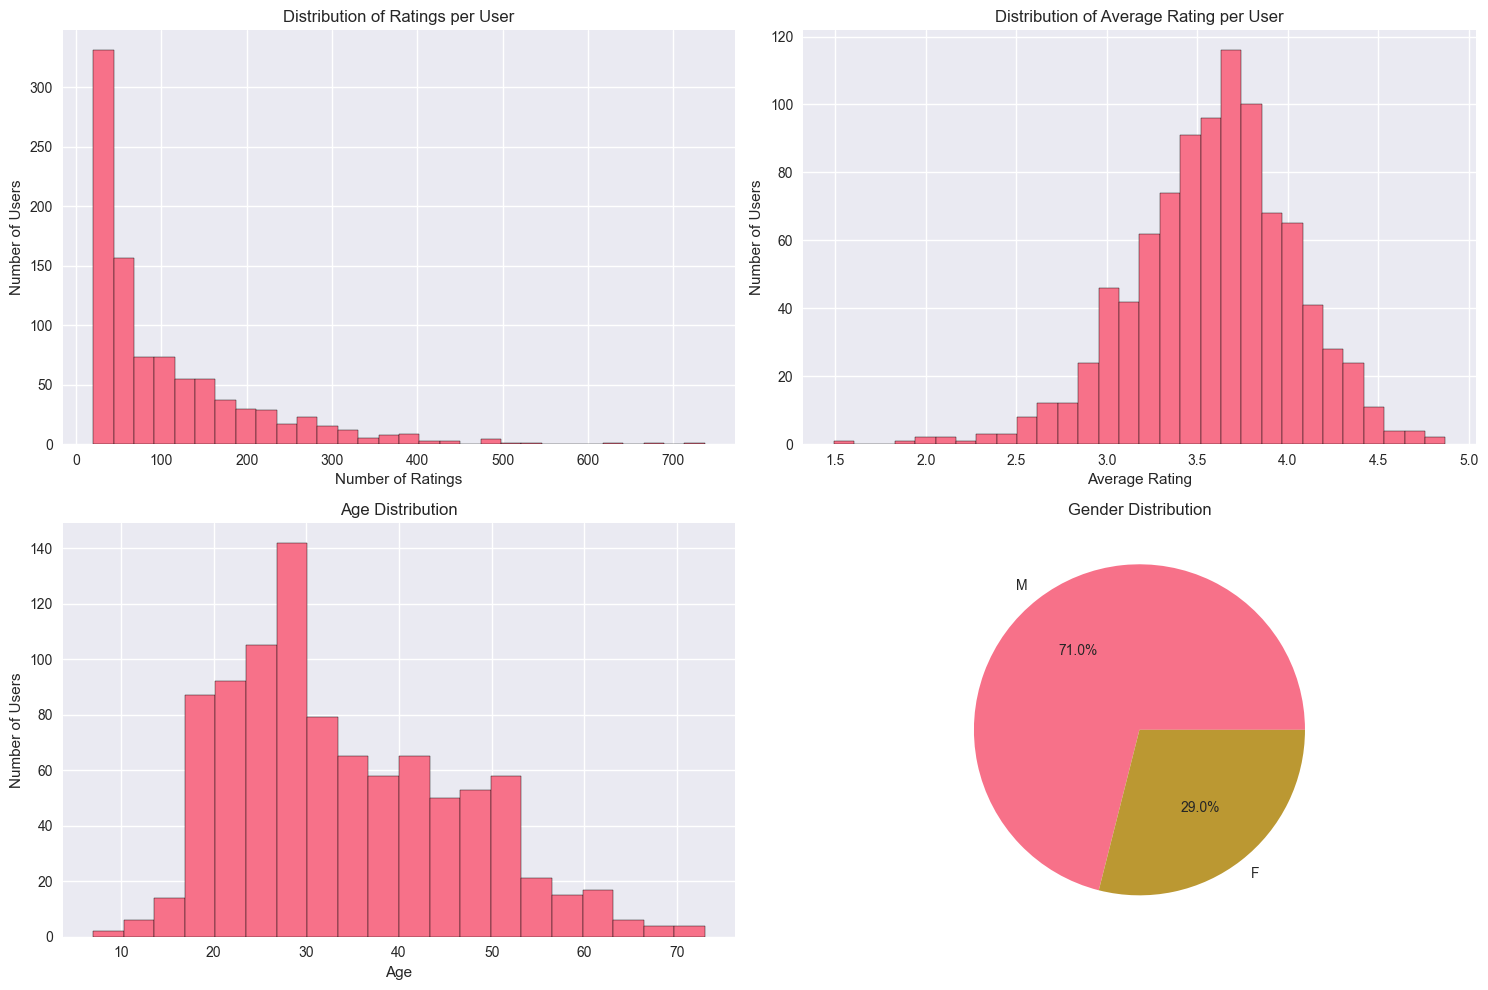

User statistics:
          user_id  num_ratings  avg_rating  rating_std
count  943.000000   943.000000  943.000000  943.000000
mean   472.000000   106.044539    3.588356    1.019820
std    272.364951   100.931743    0.445136    0.205128
min      1.000000    20.000000    1.490000    0.340000
25%    236.500000    33.000000    3.320000    0.880000
50%    472.000000    65.000000    3.620000    1.010000
75%    707.500000   148.000000    3.870000    1.140000
max    943.000000   737.000000    4.870000    1.750000


In [4]:
# User rating statistics
user_stats = ratings.groupby('user_id').agg({
    'rating': ['count', 'mean', 'std']
}).round(2)
user_stats.columns = ['num_ratings', 'avg_rating', 'rating_std']
user_stats = user_stats.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Number of ratings per user
axes[0,0].hist(user_stats['num_ratings'], bins=30, edgecolor='black')
axes[0,0].set_title('Distribution of Ratings per User')
axes[0,0].set_xlabel('Number of Ratings')
axes[0,0].set_ylabel('Number of Users')

# Average rating per user
axes[0,1].hist(user_stats['avg_rating'], bins=30, edgecolor='black')
axes[0,1].set_title('Distribution of Average Rating per User')
axes[0,1].set_xlabel('Average Rating')
axes[0,1].set_ylabel('Number of Users')

# User demographics
users['age'].hist(bins=20, ax=axes[1,0], edgecolor='black')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Number of Users')

# Gender distribution
gender_counts = users['gender'].value_counts()
axes[1,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

print("User statistics:")
print(user_stats.describe())

## 4. Movie Analysis

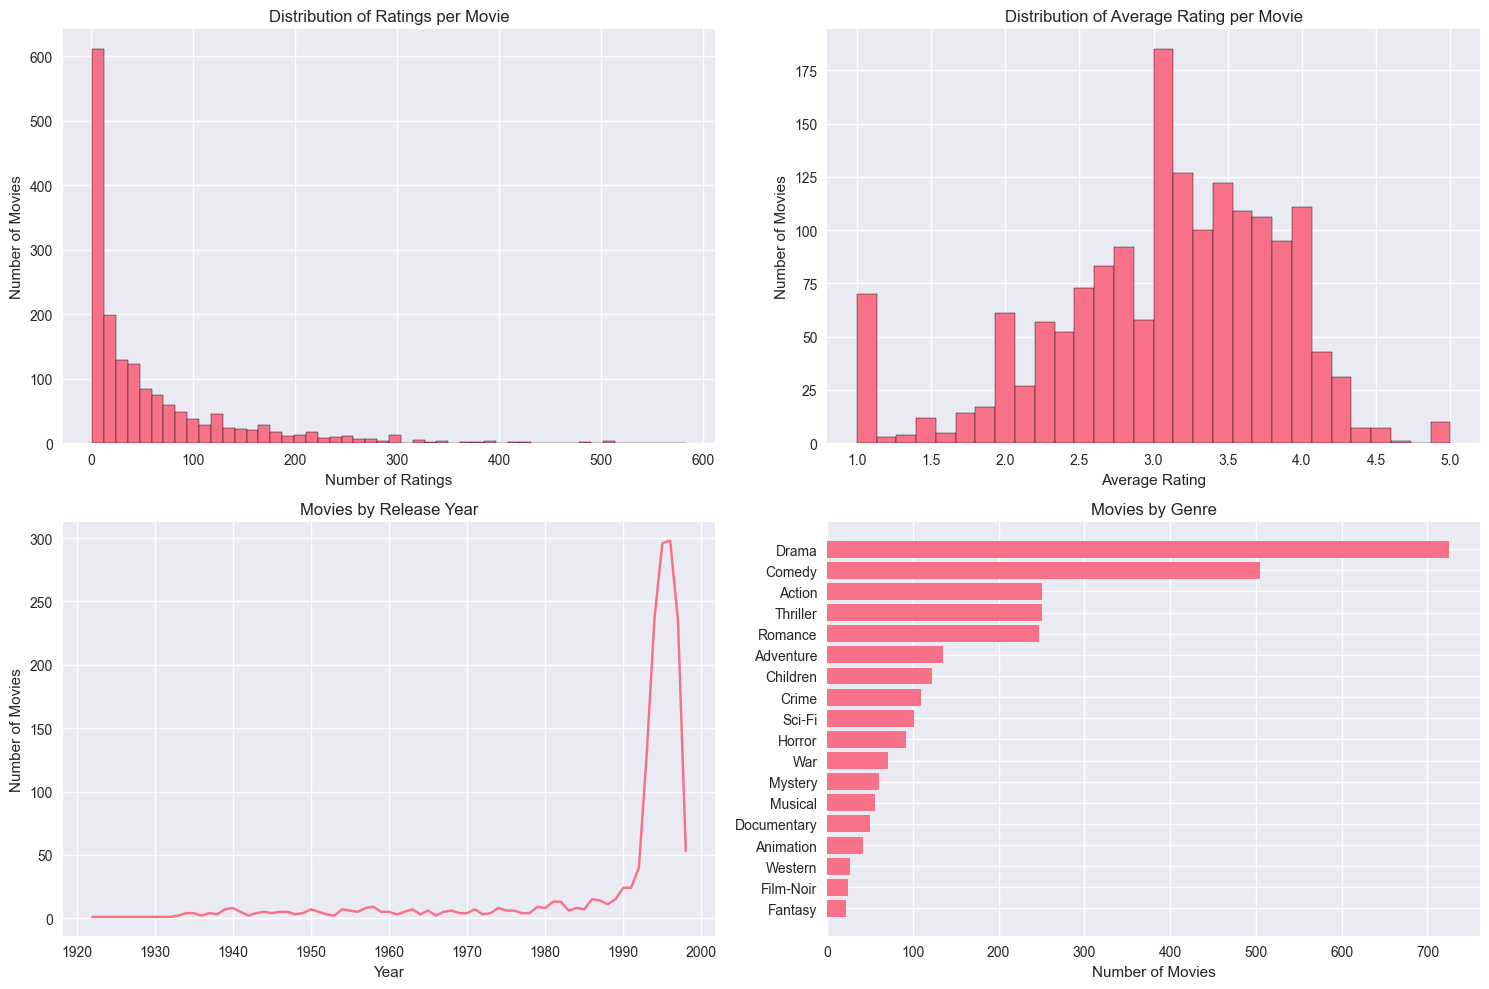


Top 10 most rated movies:
                             title  num_ratings  avg_rating
49                Star Wars (1977)          583        4.36
257                 Contact (1997)          509        3.80
99                    Fargo (1996)          508        4.16
180      Return of the Jedi (1983)          507        4.01
293               Liar Liar (1997)          485        3.16
285    English Patient, The (1996)          481        3.66
287                  Scream (1996)          478        3.44
0                 Toy Story (1995)          452        3.88
299           Air Force One (1997)          431        3.63
120  Independence Day (ID4) (1996)          429        3.44

Top 10 highest rated movies (min 50 ratings):
                                                 title  num_ratings  \
407                              Close Shave, A (1995)          112   
168                         Wrong Trousers, The (1993)          118   
317                            Schindler's List (1993

In [5]:
# Movie rating statistics
movie_stats = ratings.groupby('movie_id').agg({
    'rating': ['count', 'mean', 'std']
}).round(2)
movie_stats.columns = ['num_ratings', 'avg_rating', 'rating_std']
movie_stats = movie_stats.reset_index()

# Merge with movie info
movie_stats = movie_stats.merge(movies[['movie_id', 'title', 'year']], on='movie_id')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Number of ratings per movie
axes[0,0].hist(movie_stats['num_ratings'], bins=50, edgecolor='black')
axes[0,0].set_title('Distribution of Ratings per Movie')
axes[0,0].set_xlabel('Number of Ratings')
axes[0,0].set_ylabel('Number of Movies')

# Average rating per movie
axes[0,1].hist(movie_stats['avg_rating'], bins=30, edgecolor='black')
axes[0,1].set_title('Distribution of Average Rating per Movie')
axes[0,1].set_xlabel('Average Rating')
axes[0,1].set_ylabel('Number of Movies')

# Movies by year
year_counts = movies['year'].value_counts().sort_index()
axes[1,0].plot(year_counts.index, year_counts.values)
axes[1,0].set_title('Movies by Release Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Number of Movies')

# Top genres
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
genre_counts = movies[genre_cols].sum().sort_values(ascending=True)
axes[1,1].barh(range(len(genre_counts)), genre_counts.values)
axes[1,1].set_yticks(range(len(genre_counts)))
axes[1,1].set_yticklabels(genre_counts.index)
axes[1,1].set_title('Movies by Genre')
axes[1,1].set_xlabel('Number of Movies')

plt.tight_layout()
plt.show()

print("\nTop 10 most rated movies:")
top_movies = movie_stats.nlargest(10, 'num_ratings')[['title', 'num_ratings', 'avg_rating']]
print(top_movies)

print("\nTop 10 highest rated movies (min 50 ratings):")
high_rated = movie_stats[movie_stats['num_ratings'] >= 50].nlargest(10, 'avg_rating')[['title', 'num_ratings', 'avg_rating']]
print(high_rated)

## 5. Rating Matrix Analysis

Rating matrix shape: (943, 1682)
Total possible ratings: 1,586,126
Actual ratings: 100,000
Sparsity: 93.70%


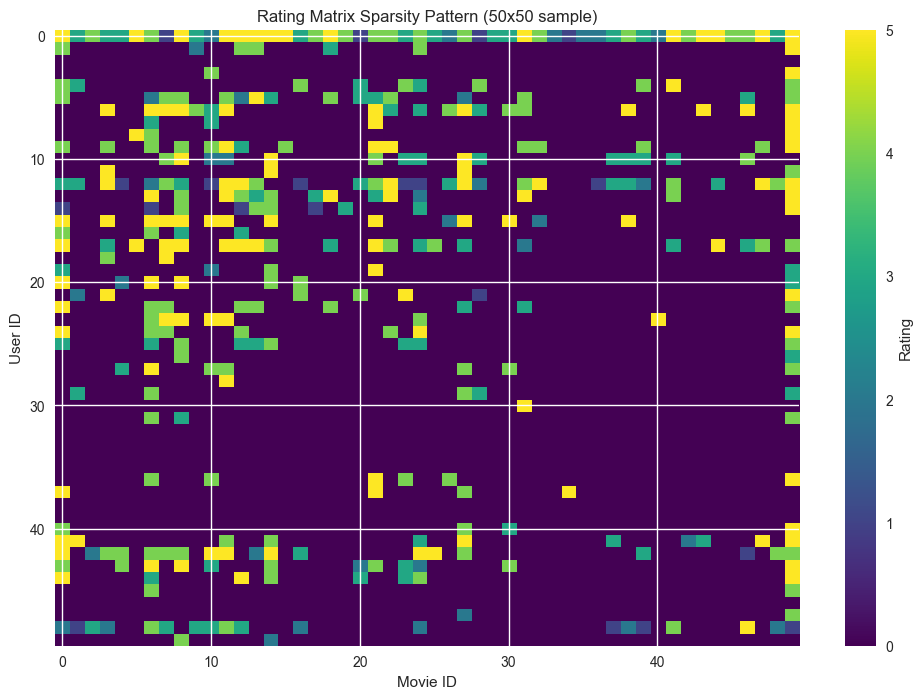


=== Cold Start Analysis ===
Users with ≤5 ratings: 0 (0.0%)
Movies with ≤5 ratings: 384 (22.8%)


In [6]:
# Create rating matrix
rating_matrix = loader.create_rating_matrix(ratings)

print(f"Rating matrix shape: {rating_matrix.shape}")
print(f"Total possible ratings: {rating_matrix.shape[0] * rating_matrix.shape[1]:,}")
print(f"Actual ratings: {len(ratings):,}")
print(f"Sparsity: {(1 - len(ratings) / (rating_matrix.shape[0] * rating_matrix.shape[1])) * 100:.2f}%")

# Visualize sparsity pattern (sample)
sample_matrix = rating_matrix.iloc[:50, :50]  # Sample 50x50 for visualization

plt.figure(figsize=(12, 8))
plt.imshow(sample_matrix.values, cmap='viridis', aspect='auto')
plt.colorbar(label='Rating')
plt.title('Rating Matrix Sparsity Pattern (50x50 sample)')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.show()

# Cold start analysis
print("\n=== Cold Start Analysis ===")
users_with_few_ratings = user_stats[user_stats['num_ratings'] <= 5]
movies_with_few_ratings = movie_stats[movie_stats['num_ratings'] <= 5]

print(f"Users with ≤5 ratings: {len(users_with_few_ratings)} ({len(users_with_few_ratings)/len(users)*100:.1f}%)")
print(f"Movies with ≤5 ratings: {len(movies_with_few_ratings)} ({len(movies_with_few_ratings)/len(movies)*100:.1f}%)")

## 6. Temporal Analysis

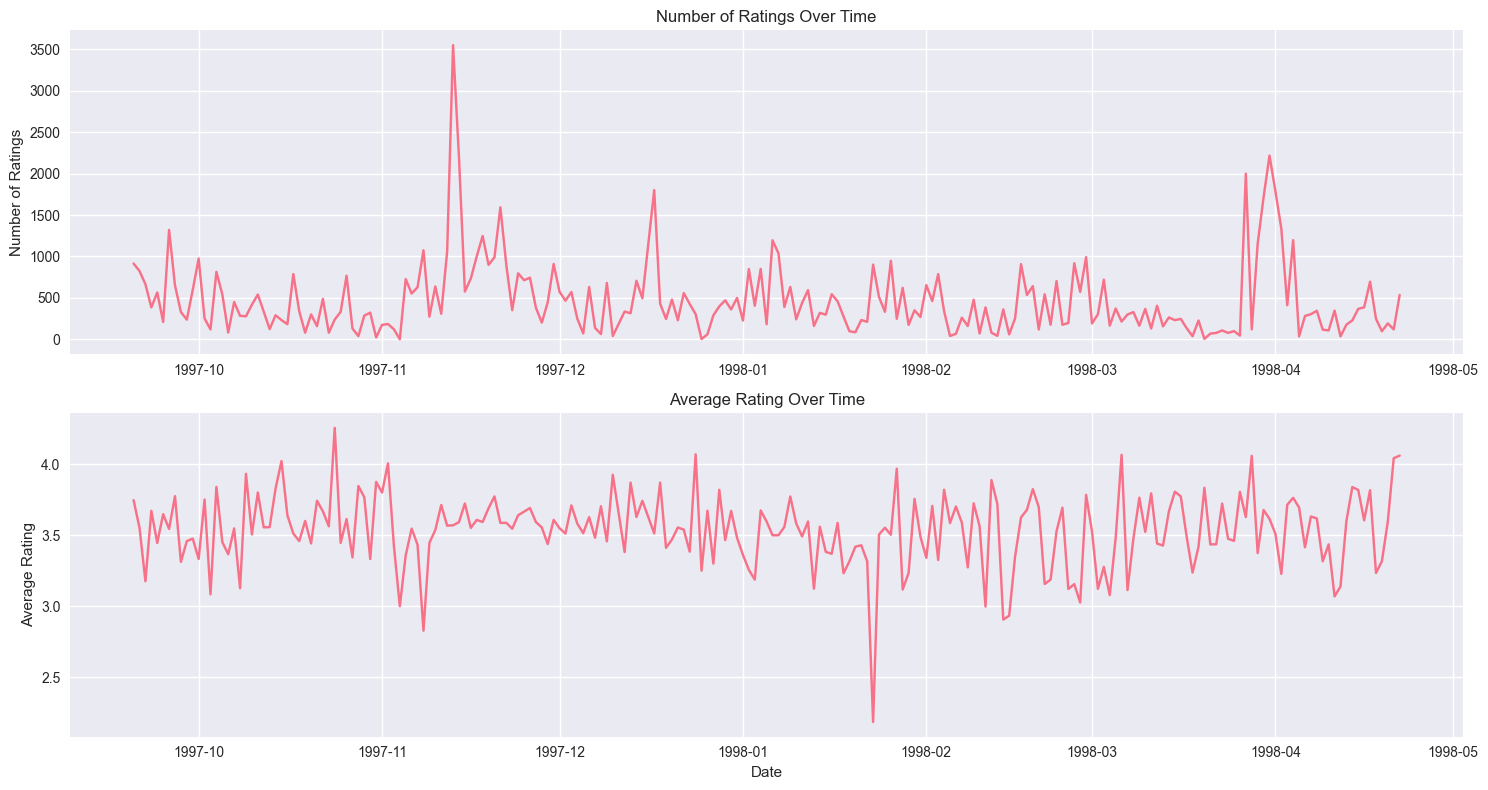

Rating period: 1997-09-20 03:05:10 to 1998-04-22 23:10:38
Peak rating day: 1997-11-13 with 3550 ratings


In [7]:
# Rating trends over time
ratings['date'] = ratings['timestamp'].dt.date
daily_ratings = ratings.groupby('date').agg({
    'rating': ['count', 'mean']
})
daily_ratings.columns = ['num_ratings', 'avg_rating']

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Number of ratings over time
axes[0].plot(daily_ratings.index, daily_ratings['num_ratings'])
axes[0].set_title('Number of Ratings Over Time')
axes[0].set_ylabel('Number of Ratings')

# Average rating over time
axes[1].plot(daily_ratings.index, daily_ratings['avg_rating'])
axes[1].set_title('Average Rating Over Time')
axes[1].set_ylabel('Average Rating')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"Rating period: {ratings['timestamp'].min()} to {ratings['timestamp'].max()}")
print(f"Peak rating day: {daily_ratings['num_ratings'].idxmax()} with {daily_ratings['num_ratings'].max()} ratings")